# Taskp 8.1P - Josh Hulett

---
### Libraries:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---
### Question 1:

In [ ]:
# Read dataset
df = pd.read_csv("Real_Estate.csv")

In [4]:
df.head()

,Address,Property Type,Bedrooms,Bathrooms,Parking Spaces,Study,Sold Price,Sold Date,Size,Suburb
0,"11/36 Lisson Grove, Hawthorn, Vic 3122",Apartment,1,1,1,0,"710,000",19/05/2026,NaN,Hawthorn
1,"2/4-6 Grattan Street, Hawthorn, Vic 3122",Apartment,2,1,1,0,"900,000",16/05/2026,NaN,Hawthorn
2,"16/25 Malmsbury Street, Hawthorn, Vic 3122",Townhouse,2,2,2,0,"1,000,000",11/05/2026,NaN,Hawthorn
3,"13/284 Barkers Road, Hawthorn, Vic 3122",Unit,2,1,1,0,"928,000",9/05/2026,208,Hawthorn
4,"6/4 Hill Street, Hawthorn, Vic 3122",Apartment,2,1,1,0,"712,500",9/05/2026,NaN,Hawthorn


In [5]:
# Drop address column
df = df.drop(columns=['Address'])

df.head()

,Property Type,Bedrooms,Bathrooms,Parking Spaces,Study,Sold Price,Sold Date,Size,Suburb
0,Apartment,1,1,1,0,"710,000",19/05/2026,NaN,Hawthorn
1,Apartment,2,1,1,0,"900,000",16/05/2026,NaN,Hawthorn
2,Townhouse,2,2,2,0,"1,000,000",11/05/2026,NaN,Hawthorn
3,Unit,2,1,1,0,"928,000",9/05/2026,208,Hawthorn
4,Apartment,2,1,1,0,"712,500",9/05/2026,NaN,Hawthorn


### General cleaning

In [6]:
# Ensure consistent naming conventions
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Ensure sold price is formatted and numeric
df['sold_price'] = df['sold_price'].str.replace(',', '').astype(float)

# Make size numeric
df['size'] = pd.to_numeric(df['size'], errors='coerce')

# Ensure sold_data is in a datetime
df['sold_date'] = pd.to_datetime(df['sold_date'], format='%d/%m/%Y')

df.head()

,property_type,bedrooms,bathrooms,parking_spaces,study,sold_price,sold_date,size,suburb
0,Apartment,1,1,1,0,710000.0,2026-05-19,NaN,Hawthorn
1,Apartment,2,1,1,0,900000.0,2026-05-16,NaN,Hawthorn
2,Townhouse,2,2,2,0,1000000.0,2026-05-11,NaN,Hawthorn
3,Unit,2,1,1,0,928000.0,2026-05-09,208.0,Hawthorn
4,Apartment,2,1,1,0,712500.0,2026-05-09,NaN,Hawthorn


In [7]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

print(missing_values)

                Missing Values  Percentage
property_type                0    0.000000
bedrooms                     0    0.000000
bathrooms                    0    0.000000
parking_spaces               0    0.000000
study                        0    0.000000
sold_price                   0    0.000000
sold_date                    0    0.000000
size                        81   49.390244
suburb                       0    0.000000


In [8]:
# Drop size column - high missingness
df = df.drop(columns=['size'])

### Feature Engineering

In [9]:
# Total rooms (bedroom + bathroom)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# Bed to Bath ratio
df['bed_to_bath_ration'] = df['bedrooms'] / df['bathrooms']

# Parking spaces per bedroom
df['parking_per_bedroom'] = df['parking_spaces'] / df['bedrooms']

# Study into boolean
df.rename(columns={'study': 'has_study'}, inplace=True)

df['has_study'] = df['has_study'].astype(int)

sold_price = df.pop('sold_price')
df['sold_price'] = sold_price

df.head()

,property_type,bedrooms,bathrooms,parking_spaces,has_study,sold_date,suburb,total_rooms,bed_to_bath_ration,parking_per_bedroom,sold_price
0,Apartment,1,1,1,0,2026-05-19,Hawthorn,2,1.0,1.0,710000.0
1,Apartment,2,1,1,0,2026-05-16,Hawthorn,3,2.0,0.5,900000.0
2,Townhouse,2,2,2,0,2026-05-11,Hawthorn,4,1.0,1.0,1000000.0
3,Unit,2,1,1,0,2026-05-09,Hawthorn,3,2.0,0.5,928000.0
4,Apartment,2,1,1,0,2026-05-09,Hawthorn,3,2.0,0.5,712500.0


### Visualisations

Text(0.5, 1.0, 'Feature Correlation with Sold Price')

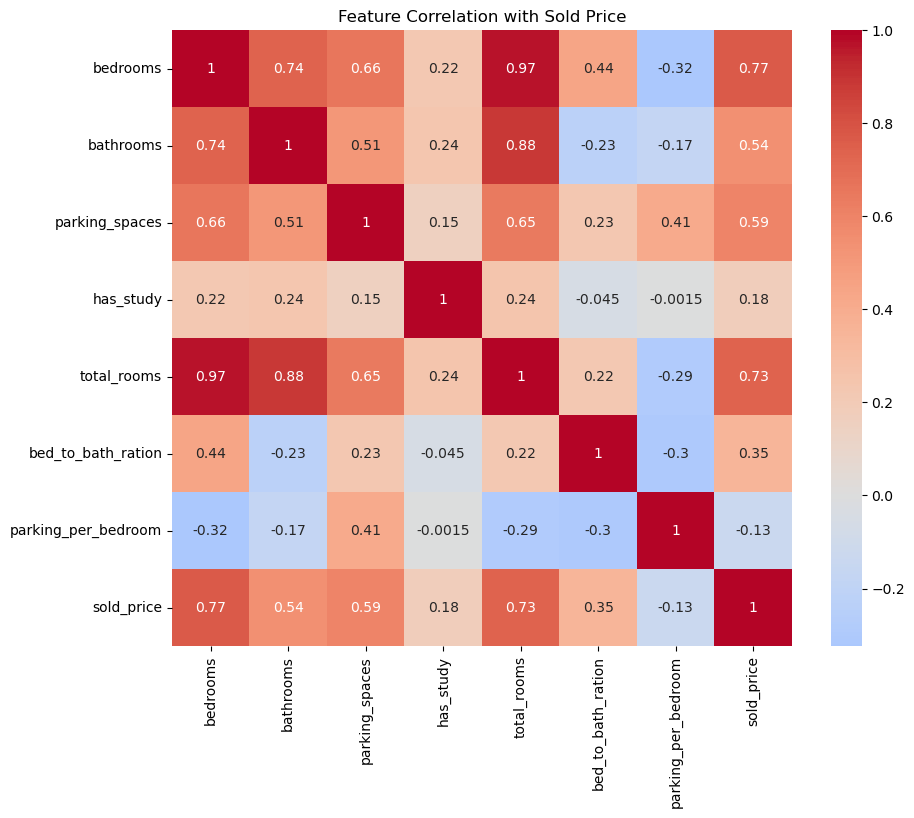

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Sold Price')

Text(0, 0.5, 'Sold Price($100,000)')

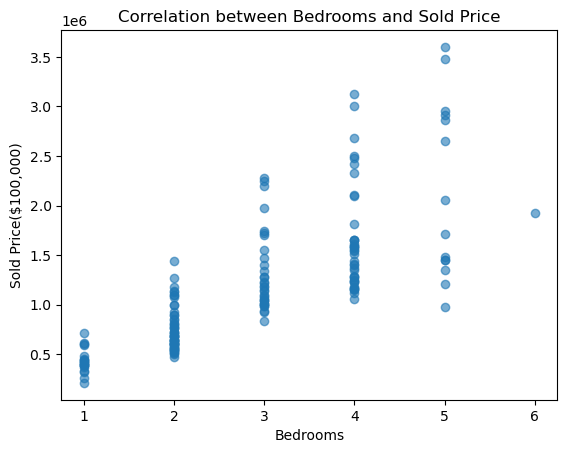

In [ ]:
# Bedroom Price correlation
plt.scatter(df['bedrooms'], df['sold_price'], alpha=0.6)
plt.title('Correlation between Bedrooms and Sold Price')
plt.xlabel('Bedrooms')
plt.ylabel('Sold Price($100,000)')

Text(0, 0.5, 'Sold Price ($100,000)')

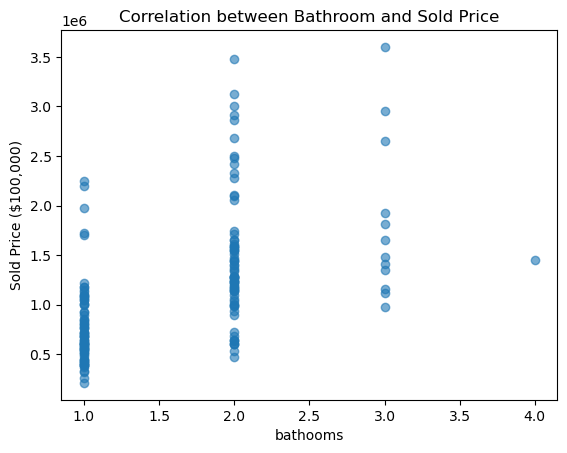

In [ ]:
# Bathroom price correlation
plt.scatter(df['bathrooms'], df['sold_price'], alpha=0.6)
plt.title('Correlation between Bathroom and Sold Price')
plt.xlabel('bathooms')
plt.ylabel('Sold Price ($100,000)')

In [13]:
# Get the record with highest sold price
most_bedrooms = df[df['bedrooms'] == df['bedrooms'].max()]
most_bathrooms = df[df['bathrooms'] == df['bathrooms'].max()]
highest_price = df[df['sold_price'] == df['sold_price'].max()]

In [14]:
most_bedrooms

,property_type,bedrooms,bathrooms,parking_spaces,has_study,sold_date,suburb,total_rooms,bed_to_bath_ration,parking_per_bedroom,sold_price
121,House,6,3,4,0,2026-03-30,Ringwood_North,9,2.0,0.666667,1920000.0


In [15]:
most_bathrooms

,property_type,bedrooms,bathrooms,parking_spaces,has_study,sold_date,suburb,total_rooms,bed_to_bath_ration,parking_per_bedroom,sold_price
112,House,5,4,2,1,2026-05-06,Ringwood_North,9,1.25,0.4,1450000.0


In [16]:
highest_price

,property_type,bedrooms,bathrooms,parking_spaces,has_study,sold_date,suburb,total_rooms,bed_to_bath_ration,parking_per_bedroom,sold_price
68,House,5,3,3,0,2026-03-18,Camberwell,8,1.666667,0.6,3600000.0


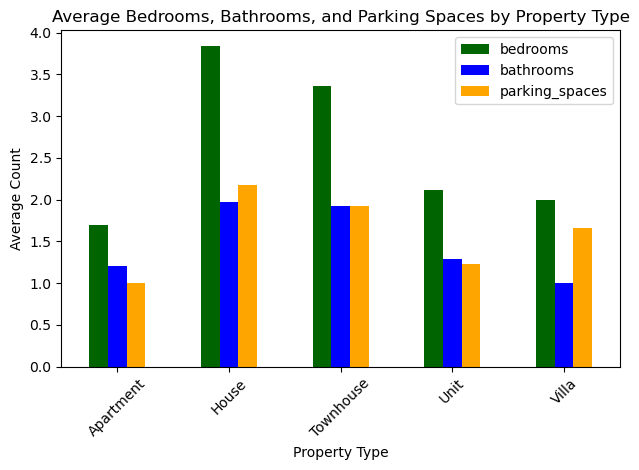

In [ ]:
# Bedrooms, bathrooms, parking spaces per property type
property_feature = df.groupby('property_type')[['bedrooms', 'bathrooms', 'parking_spaces']].mean()

plot = property_feature.plot(kind='bar', color=['darkgreen', 'blue', 'orange'])
plt.xlabel('Property Type')
plt.ylabel('Average Count')
plt.title('Average Bedrooms, Bathrooms, and Parking Spaces by Property Type')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

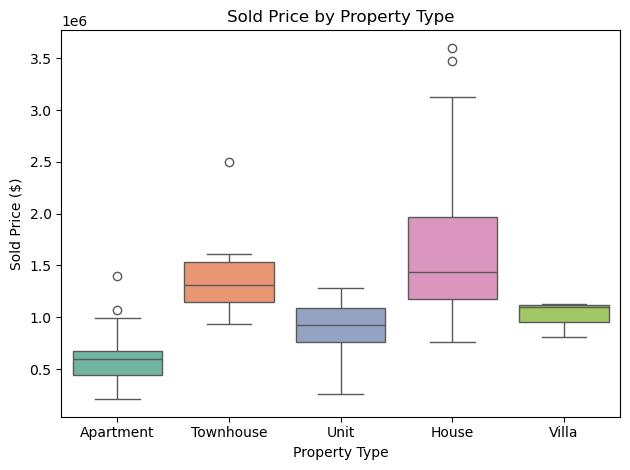

In [ ]:
# Sold price by property type
sns.boxplot(data=df, x='property_type', y='sold_price', hue='property_type', palette='Set2')
plt.title('Sold Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Sold Price ($)')
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

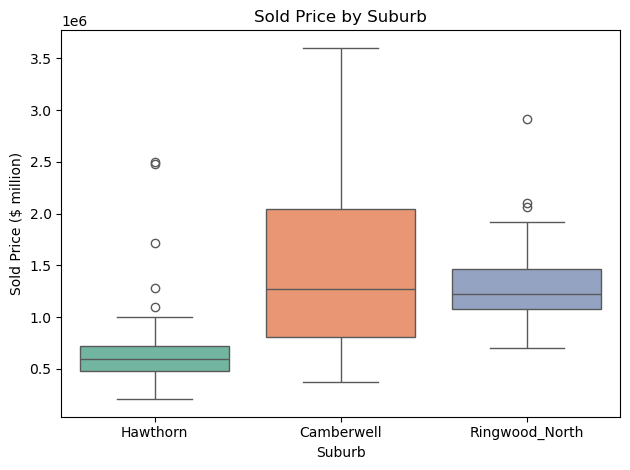

In [ ]:
# Sold price by suburb
sns.boxplot(data=df, x='suburb', y='sold_price', hue='suburb', palette='Set2')
plt.title('Sold Price by Suburb')
plt.xlabel('Suburb')
plt.ylabel('Sold Price ($ million)')
plt.tight_layout()
plt.show

Text(0, 0.5, 'Frequency')

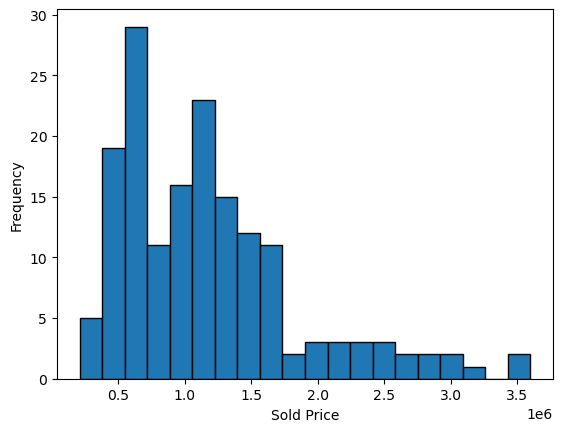

In [ ]:
# Sold price distribution
plt.hist(df['sold_price'], bins=20, edgecolor='black')
plt.xlabel('Sold Price')
plt.ylabel('Frequency')

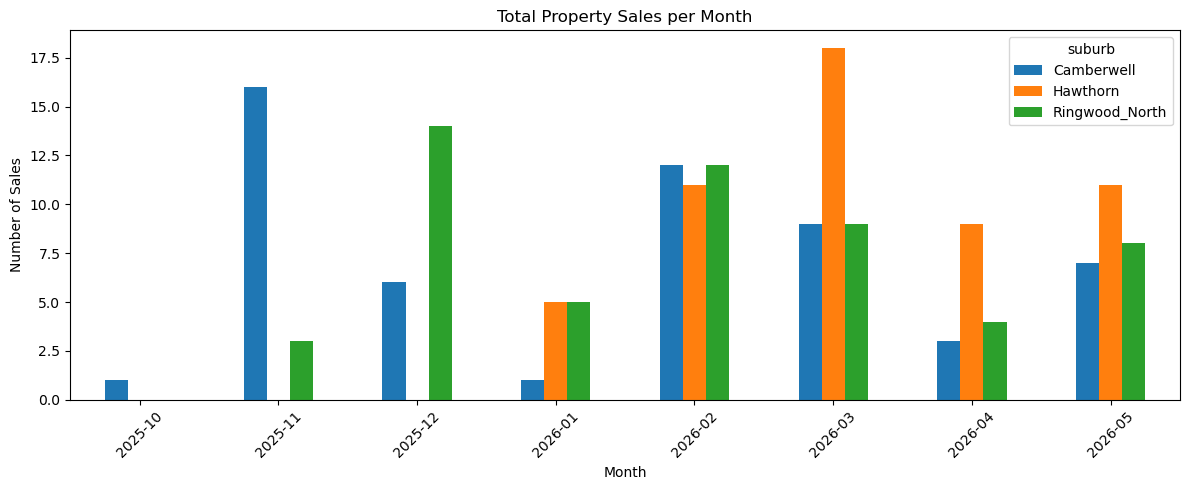

In [ ]:
# Sales per suburb by month
df['sale_month'] = df['sold_date'].dt.to_period('M')

monthly_sales = df.groupby(['sale_month', 'suburb']).size().unstack(fill_value=0)

monthly_sales.index = monthly_sales.index.to_timestamp()

plot = monthly_sales.plot(kind='bar', figsize=(12,5))
plot.set_xticklabels([d.strftime('%Y-%m') for d in monthly_sales.index], rotation=45)

plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.title('Total Property Sales per Month')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Price Trends by Suburb Over Time')

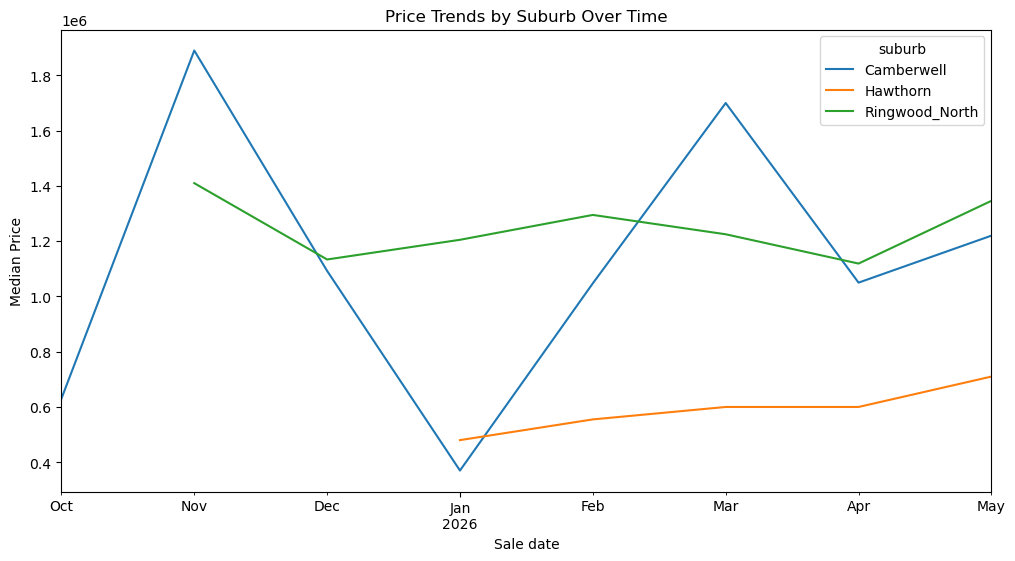

In [23]:
# Create month column
df['sale_week'] = df['sold_date'].dt.to_period('W')

# Median monthly prices per suburb
weekly_prices = (
    df.groupby(['sale_month', 'suburb'])['sold_price']
      .median()
      .unstack()
)

weekly_prices.index = weekly_prices.index.to_timestamp()
weekly_prices.plot(figsize=(12,6))
plt.xlabel('Sale date')
plt.ylabel('Median Price')
plt.title('Price Trends by Suburb Over Time')

Preprocessing pipeline

In [ ]:
y = df['sold_price']
X = df.drop(columns=['sold_price', 'sold_date', 'sale_month', 'sale_week'])

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
all_features = categorical_cols + numerical_cols

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

X_train_processed.columns = (X_train_processed.columns.str.replace("cat__", "").str.replace("num__", ""))
X_test_processed.columns = (X_test_processed.columns.str.replace("cat__", "").str.replace("num__", ""))

## Question 3 - Model Development

### Model 1 - Ridge Regression

In [ ]:
ridge_params  = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge.fit(X_train_processed, y_train)
ridge_best = ridge.best_estimator_
print(f"Best Ridge Params: {ridge.best_params_}")

Best Ridge Params: {'alpha': 0.1}


In [ ]:
cv_scores_ridge = cross_val_score(
    ridge_best,
    X_train_processed,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)
ridge_scores = np.sqrt(-cv_scores_ridge)

print("Ridge CV RMSE", ridge_scores)
print("Ridge CV RMSE:", np.sqrt(-cv_scores_ridge).mean())

Ridge CV RMSE [233478.01264296 394180.67347529 274467.47381907 304721.49553054
 256092.49906466]
Ridge CV RMSE: 292588.03090650635


In [27]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [ 10, 20, None],
    'min_samples_split': [2, 5]
}

rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)
rf_best = rf.best_estimator_
print(f"Best RF Params: {rf.best_params_}")

Best RF Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}


In [37]:
cv_scores_rf = cross_val_score(
    rf_best,
    X_train_processed,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

rf_scores = np.sqrt(-cv_scores_rf)

print("RF CV RMSE", rf_scores)

print("RF CV RMSE:", np.sqrt(-cv_scores_rf).mean())

RF CV RMSE [210253.83337728 381071.73872771 340526.09904369 305556.82568213
 206156.39038221]
RF CV RMSE: 288712.9774426028


In [38]:
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gb.fit(X_train_processed, y_train)
gb_best = gb.best_estimator_
print(f"Best GB Params: {gb.best_params_}")

Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [53]:
cv_scores_gb = cross_val_score(
    gb_best,
    X_train_processed,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

gb_scores = np.sqrt(-cv_scores_gb)

print("GB CV RMSE", gb_scores)

print("GB CV RMSE:", np.sqrt(-cv_scores_gb).mean())

GB CV RMSE [225449.48234801 354472.58919649 335155.32920329 324949.99414615
 208647.11530859]
GB CV RMSE: 289734.90204050613


In [ ]:
results = {}
models = {'Ridge': ridge_best, 'Random Forest': rf_best, 'Gradient Boosting': gb_best}
for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

for model, metrics in results.items():
    print(f"{model}: MAE=${metrics['MAE']:,.0f}, RMSE=${metrics['RMSE']:,.0f}, R²={metrics['R2']:.4f}")

Ridge: MAE=$199,413, RMSE=$281,680, R²=0.8329
Random Forest: MAE=$214,377, RMSE=$286,039, R²=0.8277
Gradient Boosting: MAE=$206,289, RMSE=$284,488, R²=0.8295


## Question 4


In [ ]:
# Ridge Regression feature coefficients
ridge_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_best.coef_
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print("Ridge Coefficients:")
print(ridge_coef)


Ridge Coefficients:
                         Feature    Coefficient
0     cat__suburb_Ringwood_North -855093.215397
1       cat__property_type_House  767561.264002
2                  num__bedrooms  508694.333780
3                 num__bathrooms -324925.601253
4   cat__property_type_Townhouse  312411.638840
5        cat__property_type_Unit  292316.803672
6               num__total_rooms  234429.717887
7       cat__property_type_Villa  222490.510516
8        num__bed_to_bath_ration -201038.413224
9            num__parking_spaces   86829.014829
10          cat__suburb_Hawthorn  -71245.575407
11      num__parking_per_bedroom   -6389.909443
12                num__has_study    -880.774181


In [56]:
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', key=abs, ascending=False).reset_index(drop=True)

print("Random Forest Importance:")
print(rf_importance)

Random Forest Importance:
                         Feature  Importance
0                  num__bedrooms    0.488665
1               num__total_rooms    0.148908
2     cat__suburb_Ringwood_North    0.140412
3            num__parking_spaces    0.059096
4       cat__property_type_House    0.058028
5       num__parking_per_bedroom    0.032375
6                 num__has_study    0.017011
7        num__bed_to_bath_ration    0.016150
8           cat__suburb_Hawthorn    0.012233
9        cat__property_type_Unit    0.011298
10  cat__property_type_Townhouse    0.006741
11                num__bathrooms    0.005722
12      cat__property_type_Villa    0.003362


In [57]:
gb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_best.feature_importances_
}).sort_values('Importance', key=abs, ascending=False).reset_index(drop=True)

print("Gradient Boosting Performance:")
print(gb_importance)

Gradient Boosting Performance:
                         Feature  Importance
0                  num__bedrooms    0.322968
1               num__total_rooms    0.239896
2     cat__suburb_Ringwood_North    0.202588
3       cat__property_type_House    0.082703
4            num__parking_spaces    0.059673
5       num__parking_per_bedroom    0.023549
6        num__bed_to_bath_ration    0.015745
7           cat__suburb_Hawthorn    0.015414
8   cat__property_type_Townhouse    0.014945
9                 num__has_study    0.011706
10       cat__property_type_Unit    0.007381
11      cat__property_type_Villa    0.002024
12                num__bathrooms    0.001408


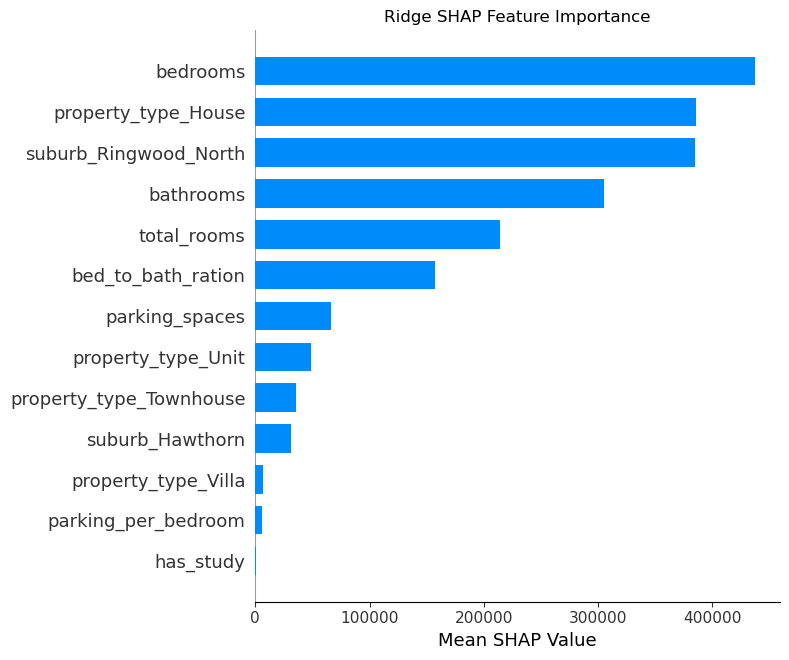

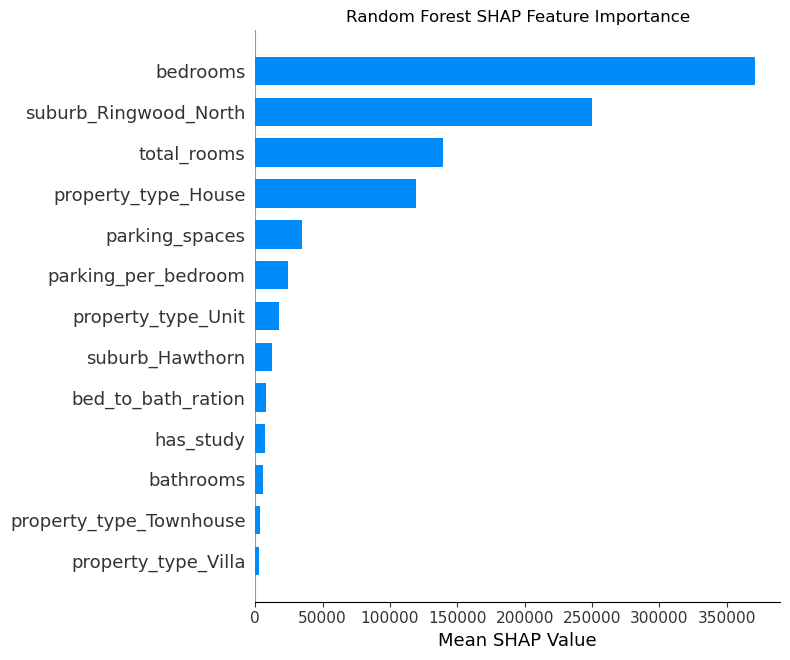

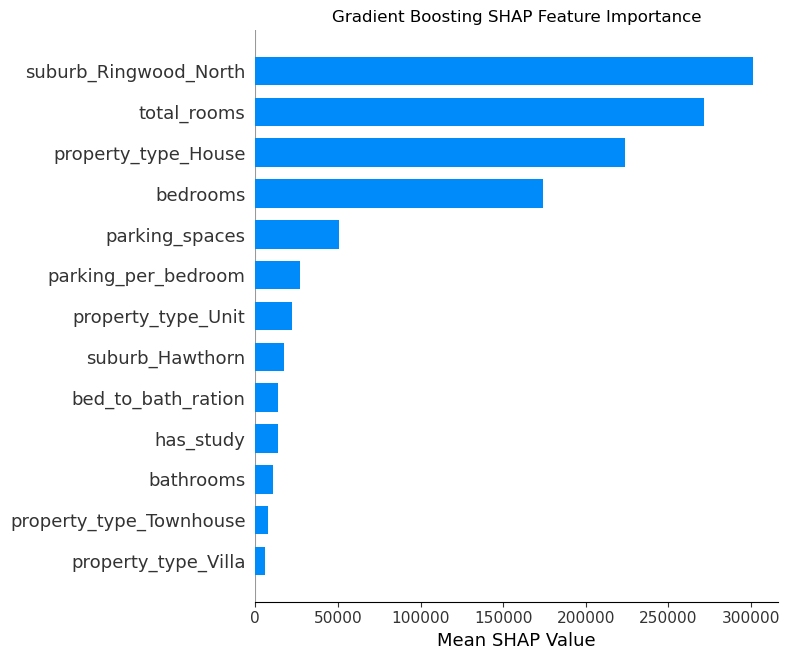

In [58]:
import shap

models = [('Ridge', ridge_best), ('Random Forest', rf_best), ('Gradient Boosting', gb_best)]
for name, model in models:
    explainer = shap.Explainer(model, X_train_processed)
    shap_values = explainer(X_test_processed)
    
    shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)
    plt.title(f"{name} SHAP Feature Importance")
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

## Question 5

In [ ]:
# Save models and scaler for app demo
import pickle

pickle.dump(ridge_best, open('financial_model.pkl', 'wb'))
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))

Below is the code used to deploy a simple streamlit demo where users can input each feature and get a predicted house price.

The demo using the Ridge model, as it was the best performing on the test data set.

To run the demo, I used the code in a python script and ran it using `streamlit run app.py` in the terminal.

```
import streamlit as st
import pandas as pd
import pickle
import numpy as np

st.title("Melbourne Housing Price Predictor")

with open('financial_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

suburb = st.selectbox("Suburb", ["Hawthorn", "Camberwell", "Ringwood_North"])
bedrooms = st.slider("Bedroom", 1, 6, 3)
bathrooms = st.slider("Bathroom", 1, 4, 2)
parking = st.slider("Parking Spaces", 0, 5, 2)
property_type = st.selectbox("Property Type", ["House", "Apartment", "Townhouse", "Villa", "Unit"])
has_study = st.checkbox("Has Study")

input_data = pd.DataFrame({
    'property_type': [property_type],
    'bedrooms': [bedrooms],
    'bathrooms': [bathrooms],
    'parking_spaces': [parking],
    'has_study': [int(has_study)],
    'size': [100],
    'suburb': [suburb],
    'total_rooms': [bedrooms + bathrooms],
    'bed_to_bath_ration': [bedrooms / bathrooms],
    "parking_per_bedroom": [parking / bedrooms]
})

if st.button("Predict Price"):
    input_transformed = preprocessor.transform(input_data)
    prediction = model.predict(input_transformed)[0]
    st.success(f"Estiamted Price: ${prediction:,.0f}")
```

### Question 6

In [ ]:
from sklearn.model_selection import KFold

# Creating a 5-Fold split
kfolds = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(kfolds.split(X_train_processed))

# Take the first fold
train_idx, val_idx = folds[0]

# Prepare fold data
X_fold_train = X_train_processed.iloc[train_idx]
X_fold_val = X_train_processed.iloc[val_idx]

y_fold_train = y_train.iloc[train_idx]
y_fold_val = y_train.iloc[val_idx]

In [ ]:
# Prepare llm data for training
llm_train_df = X_fold_train.copy()
llm_train_df["sold_price"] = y_fold_train.values

llm_train_df.to_csv("llm_training_data.csv", index=False)

In [ ]:
# Prepare llm validation data
llm_test_df = X_fold_val.copy()

llm_test_df.to_csv("llm_validation_data.csv", index=False)

In [ ]:
# Load predictions made by the llm
llm_predict_df = pd.read_csv("llm_predictions.csv")
llm_predict_df.head()

,property_type_House,property_type_Townhouse,property_type_Unit,property_type_Villa,suburb_Hawthorn,suburb_Ringwood_North,bedrooms,bathrooms,parking_spaces,has_study,total_rooms,bed_to_bath_ration,parking_per_bedroom,predicted_sold_price
0,0.0,0.0,0.0,0.0,1.0,0.0,-1.522163,-0.983092,-0.806491,-0.373002,-1.425658,-1.324074,1.538689,4.234187e+05
1,0.0,0.0,0.0,1.0,0.0,0.0,-0.698182,-0.983092,0.394081,-0.373002,-0.851008,0.334447,1.538689,8.150883e+05
2,1.0,0.0,0.0,0.0,0.0,1.0,0.949779,0.568535,0.394081,-0.373002,0.872941,0.334447,-0.472301,1.344838e+06
3,0.0,0.0,0.0,0.0,1.0,0.0,-0.698182,0.568535,-0.806491,-0.373002,-0.276358,-1.324074,-0.472301,6.494805e+05
4,0.0,0.0,1.0,0.0,0.0,0.0,-0.698182,-0.983092,-0.806491,-0.373002,-0.851008,0.334447,-0.472301,1.030147e+06


In [ ]:
# Calculate MAE, RMSE, and R2 for the llm predictions
y_true = y_fold_val.copy()
y_pred = llm_predict_df['predicted_sold_price']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE (Mean Absolute Error): ${mae:,.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE (Mean Absolute Error): $227,496.32
RMSE (Root Mean Squared Error): $316,572.07
R² Score: 0.5318


In [ ]:
# Calculate MAE, RMSE, and R2 for Ridge Regression predictions
y_true = y_fold_val.copy()
y_pred = ridge_best.predict(X_fold_val)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE (Mean Absolute Error): ${mae:,.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE (Mean Absolute Error): $138,086.39
RMSE (Root Mean Squared Error): $206,961.88
R² Score: 0.7999
